# Baselines — ML Imputation (Univariate)
This notebook implements univariate ML baselines for time-series imputation using lag-based features.

**Included methods**
- KNN Regressor (lag feature regression)
- Ridge Regression (lag feature regression)
- Histogram-based Gradient Boosting Regressor (lag feature regression)
- IterativeImputer (BayesianRidge) on a lag/Hankel matrix (MICE-style)

**Masking**
- Random missingness + forced boundary missingness (matches the statistical baseline notebook).

**Assumptions**
- `../data/dataset.csv` exists in the current working directory.
- You have `numpy`, `pandas`, and `scikit-learn` installed.

In [2]:
# === Section: Imports ===
import numpy as np
import pandas as pd

In [3]:
# # === Section: Load Data ===
# col_names = ['date', 'time', 'epoch', 'moteid', 'temperature', 'humidity', 'light', 'voltage']
# df = pd.read_csv('../data.txt', sep=r'\s+', names=col_names, header=None)

# sensor_id = 1
# df = df[df.moteid == sensor_id].sort_values(['date', 'time']).reset_index(drop=True)
# df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
# df = df.set_index('datetime')

# data = df['temperature'].astype(float).values
# N = len(data)
# print(f'Loaded {N} readings for sensor {sensor_id}')

In [4]:
# New Dataset https://www.kaggle.com/datasets/olaflundstrom/sensor-data/code
DATASET = '../data/dataset1.csv'
df = pd.read_csv(DATASET)
df.sort_values('datetime', inplace=True)
df.set_index('datetime', inplace=True)
temperature_series = df['temperature'].astype(float)
data = temperature_series.values
N = len(data)
print("Loaded dataset with shape:", df.shape)
print(f"Loaded {N} temperature readings.")

Loaded dataset with shape: (26387, 2)
Loaded 26387 temperature readings.


In [11]:
# === Section: Masking (Per-position masks) ===
def build_mask(n: int, missing_rate: float = 0.3, seed: int = 42, boundary: int = 5) -> np.ndarray:
    rng = np.random.default_rng(seed)
    mask = np.ones(n, dtype=bool)
    missing_indices = rng.choice(n, size=int(n * missing_rate), replace=False)
    mask[missing_indices] = False
    if boundary > 0:
        mask[:boundary] = False
        mask[-boundary:] = False
    return mask

missing_rate = 0.3
seed = 42
boundary = 5
missing_positions = ['START', 'MIDDLE', 'END', 'RANDOM']
missing_count = max(1, int(round(N * missing_rate)))

def build_missing_mask(position):
    mask = np.ones(N, dtype=bool)
    if position == 'START':
        mask[:missing_count] = False
    elif position == 'MIDDLE':
        start = max(0, (N - missing_count) // 2)
        end = start + missing_count
        mask[start:end] = False
    elif position == 'END':
        mask[-missing_count:] = False
    elif position == 'RANDOM':
        rng = np.random.default_rng(seed)
        missing_indices = rng.choice(N, size=missing_count, replace=False)
        mask[missing_indices] = False
    else:
        raise ValueError(f'Unknown missing position: {position}')
    return mask

missing_masks = {pos: build_missing_mask(pos) for pos in missing_positions}

for pos, m in missing_masks.items():
    print(f"{pos:<6} masked points: {(~m).sum()} / {N} ({(~m).mean()*100:.1f}%)")

START  masked points: 7916 / 26387 (30.0%)
MIDDLE masked points: 7916 / 26387 (30.0%)
END    masked points: 7916 / 26387 (30.0%)
RANDOM masked points: 7916 / 26387 (30.0%)


In [6]:
# === Section: Feature Engineering (Lagged Values + Lagged Masks) ===
def make_lag_features(values_filled: np.ndarray, mask: np.ndarray, max_lag: int) -> np.ndarray:
    n = len(values_filled)
    m_float = mask.astype(np.float32)
    feats = []
    for k in range(1, max_lag + 1):
        xk = np.roll(values_filled, k)
        mk = np.roll(m_float, k)
        xk[:k] = 0.0
        mk[:k] = 0.0
        feats.append(xk)
    for k in range(1, max_lag + 1):
        mk = np.roll(m_float, k)
        mk[:k] = 0.0
        feats.append(mk)
    return np.stack(feats, axis=1)

max_lag = 48
X = make_lag_features(observed_filled, mask, max_lag=max_lag)
y = data.astype(np.float32)

train_idx = np.where(mask)[0]
test_idx = np.where(~mask)[0]
X_train, y_train = X[train_idx], y[train_idx]
X_test = X[test_idx]

In [12]:
# === Section: ML Baselines (Fit + Impute + Metrics) — per missingness position ===
def report_metrics(name: str, imputed: np.ndarray, data: np.ndarray, mask: np.ndarray) -> dict:
    missing_true = data[~mask]
    missing_pred = imputed[~mask]
    mae = float(np.mean(np.abs(missing_pred - missing_true)))
    rmse = float(np.sqrt(np.mean((missing_pred - missing_true) ** 2)))
    return {"MAE": mae, "RMSE": rmse}

try:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.linear_model import Ridge, BayesianRidge
    from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401
    from sklearn.impute import IterativeImputer
except ImportError as e:
    raise ImportError("scikit-learn is required. Install with: pip install scikit-learn") from e

baseline_names = ["KNN Regressor", "Ridge Regression", "HistGradientBoosting", "IterativeImputer (BR)"]
results = {}

for position, mask in missing_masks.items():
    print(f"\nEvaluating position: {position}")
    # Rebuild observed_filled and lag features for this mask
    observed_filled = data.copy().astype(np.float32)
    observed_filled[~mask] = 0.0
    X = make_lag_features(observed_filled, mask, max_lag=max_lag)
    y = data.astype(np.float32)
    train_idx = np.where(mask)[0]
    test_idx = np.where(~mask)[0]
    X_train, y_train = X[train_idx], y[train_idx]
    X_test = X[test_idx]

    pos_metrics = {}
    imputations = {}

    # 1) KNN Regressor
    knn = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor(n_neighbors=5, weights="distance")),])
    knn.fit(X_train, y_train)
    imputed_knn = data.copy().astype(np.float32)
    imputed_knn[test_idx] = knn.predict(X_test).astype(np.float32)
    pos_metrics['KNN Regressor'] = report_metrics('KNN Regressor', imputed_knn, data, mask)
    imputations['KNN Regressor'] = imputed_knn

    # 2) Ridge Regression
    ridge = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0, random_state=seed)),])
    ridge.fit(X_train, y_train)
    imputed_ridge = data.copy().astype(np.float32)
    imputed_ridge[test_idx] = ridge.predict(X_test).astype(np.float32)
    pos_metrics['Ridge Regression'] = report_metrics('Ridge Regression', imputed_ridge, data, mask)
    imputations['Ridge Regression'] = imputed_ridge

    # 3) HistGradientBoosting
    hgb = HistGradientBoostingRegressor(random_state=seed, max_depth=6, learning_rate=0.05)
    hgb.fit(X_train, y_train)
    imputed_hgb = data.copy().astype(np.float32)
    imputed_hgb[test_idx] = hgb.predict(X_test).astype(np.float32)
    pos_metrics['HistGradientBoosting'] = report_metrics('HistGradientBoosting', imputed_hgb, data, mask)
    imputations['HistGradientBoosting'] = imputed_hgb

    # 4) IterativeImputer (BayesianRidge) on lag/Hankel matrix
    x_nan = data.copy().astype(np.float32)
    x_nan[~mask] = np.nan
    lag_mat = [x_nan]
    for k in range(1, max_lag + 1):
        col = np.roll(x_nan, k)
        col[:k] = np.nan
        lag_mat.append(col)
    lag_mat = np.stack(lag_mat, axis=1)  # [N, L+1]
    mice = IterativeImputer(estimator=BayesianRidge(), random_state=seed, max_iter=10, sample_posterior=False, initial_strategy="mean", skip_complete=True)
    lag_filled_mice = mice.fit_transform(lag_mat)
    imputed_mice = data.copy().astype(np.float32)
    imputed_mice[~mask] = lag_filled_mice[~mask, 0].astype(np.float32)
    pos_metrics['IterativeImputer (BR)'] = report_metrics('IterativeImputer (BR)', imputed_mice, data, mask)
    imputations['IterativeImputer (BR)'] = imputed_mice

    results[position] = {
        'metrics': pos_metrics,
        'imputations': imputations,
        'mask': mask,
    }

# Print summary
for position in missing_positions:
    print(f"\n{position} missingness")
    for name in baseline_names:
        m = results[position]['metrics'][name]
        print(f"  {name:<28} MAE: {m['MAE']:.4f}, RMSE: {m['RMSE']:.4f}")


Evaluating position: START


c:\Users\branana\Desktop\Github Repos\mphil\lvimputer\venv\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



Evaluating position: MIDDLE


c:\Users\branana\Desktop\Github Repos\mphil\lvimputer\venv\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



Evaluating position: END


c:\Users\branana\Desktop\Github Repos\mphil\lvimputer\venv\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



Evaluating position: RANDOM

START missingness
  KNN Regressor                MAE: 13.6231, RMSE: 16.7863
  Ridge Regression             MAE: 13.6231, RMSE: 16.7863
  HistGradientBoosting         MAE: 13.7788, RMSE: 16.9188
  IterativeImputer (BR)        MAE: 9.2346, RMSE: 11.5841

MIDDLE missingness
  KNN Regressor                MAE: 14.1719, RMSE: 16.0915
  Ridge Regression             MAE: 14.1898, RMSE: 16.1095
  HistGradientBoosting         MAE: 8.1973, RMSE: 11.0179
  IterativeImputer (BR)        MAE: 7.0269, RMSE: 7.9645

END missingness
  KNN Regressor                MAE: 14.4671, RMSE: 15.9828
  Ridge Regression             MAE: 14.4819, RMSE: 15.9893
  HistGradientBoosting         MAE: 11.0963, RMSE: 13.0327
  IterativeImputer (BR)        MAE: 5.8575, RMSE: 6.9472

RANDOM missingness
  KNN Regressor                MAE: 3.2709, RMSE: 4.5291
  Ridge Regression             MAE: 1.7082, RMSE: 2.4936
  HistGradientBoosting         MAE: 0.8732, RMSE: 1.8788
  IterativeImputer (BR

c:\Users\branana\Desktop\Github Repos\mphil\lvimputer\venv\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


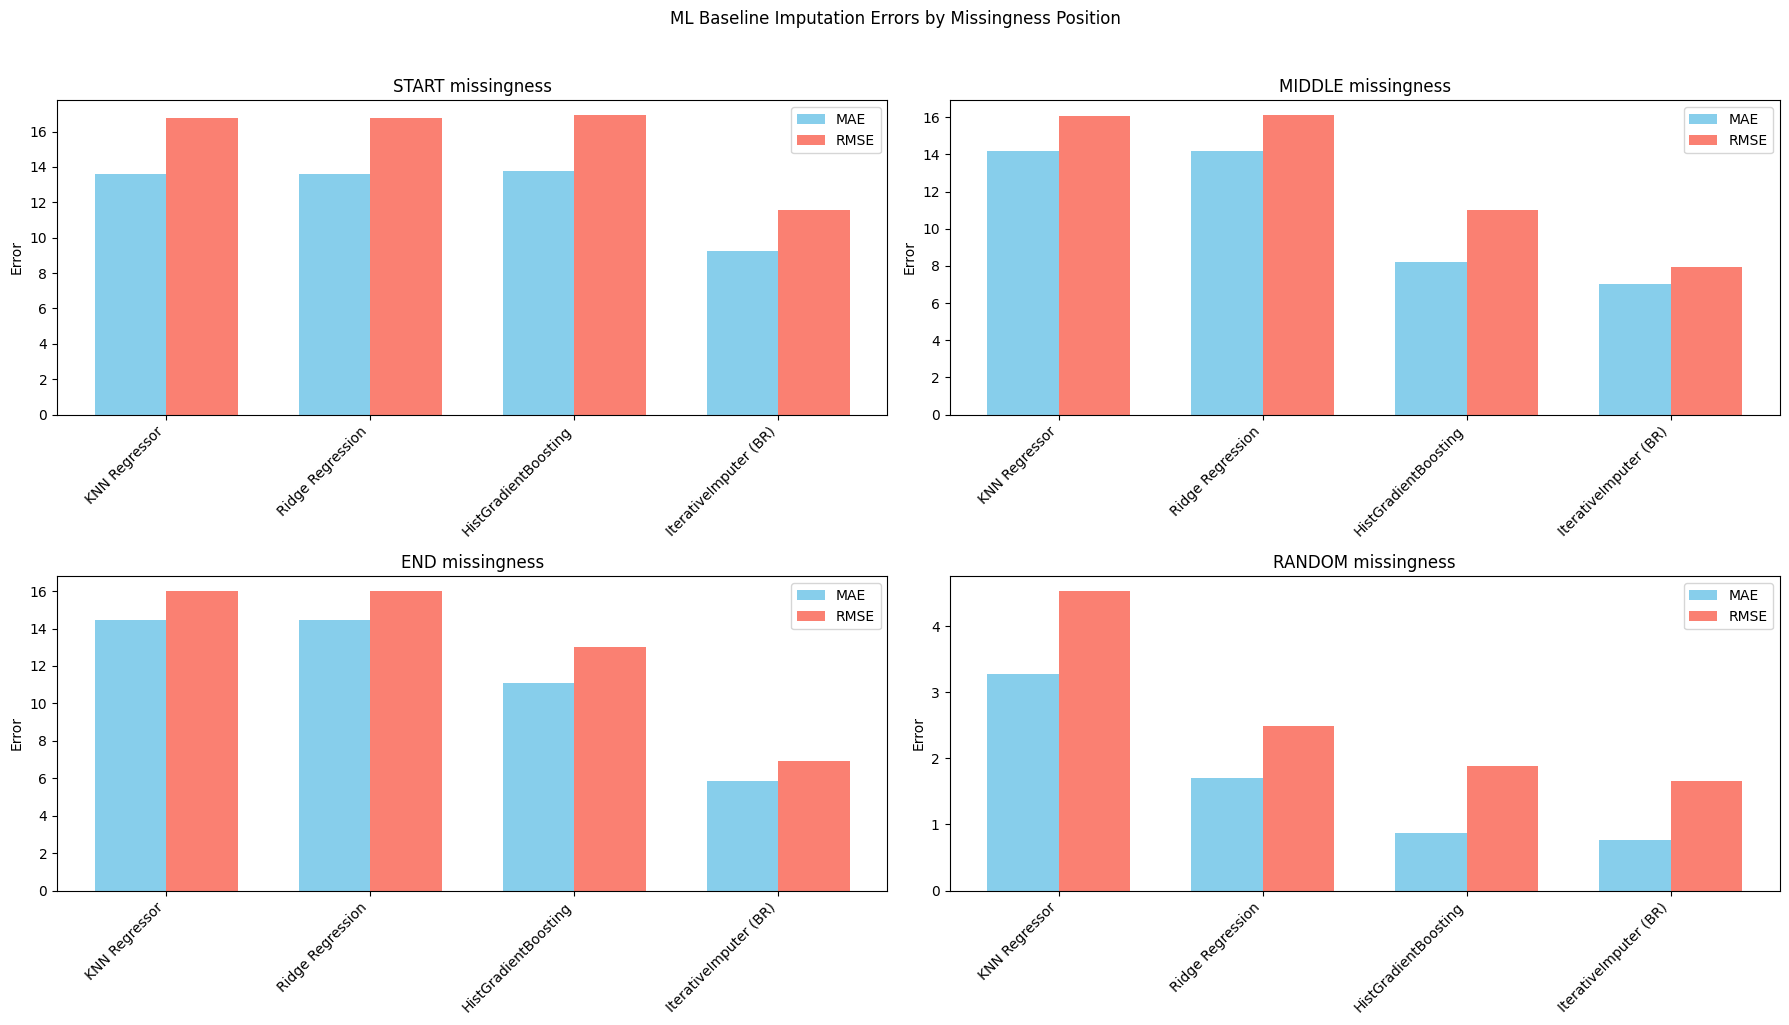

In [13]:
# === Section: Plotting I — MAE/RMSE by position ===
import matplotlib.pyplot as plt
baseline_order = ["KNN Regressor", "Ridge Regression", "HistGradientBoosting", "IterativeImputer (BR)"]
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for ax, position in zip(axes, missing_positions):
    metrics = results[position]['metrics']
    mae_values = [metrics[name]['MAE'] for name in baseline_order]
    rmse_values = [metrics[name]['RMSE'] for name in baseline_order]
    x = np.arange(len(baseline_order))
    width = 0.35
    ax.bar(x - width/2, mae_values, width, label='MAE', color='skyblue')
    ax.bar(x + width/2, rmse_values, width, label='RMSE', color='salmon')
    ax.set_xticks(x)
    ax.set_xticklabels(baseline_order, rotation=45, ha='right')
    ax.set_ylabel('Error')
    ax.set_title(f'{position} missingness')
    ax.legend()

fig.suptitle('ML Baseline Imputation Errors by Missingness Position', y=1.02)
fig.tight_layout()
plt.show()

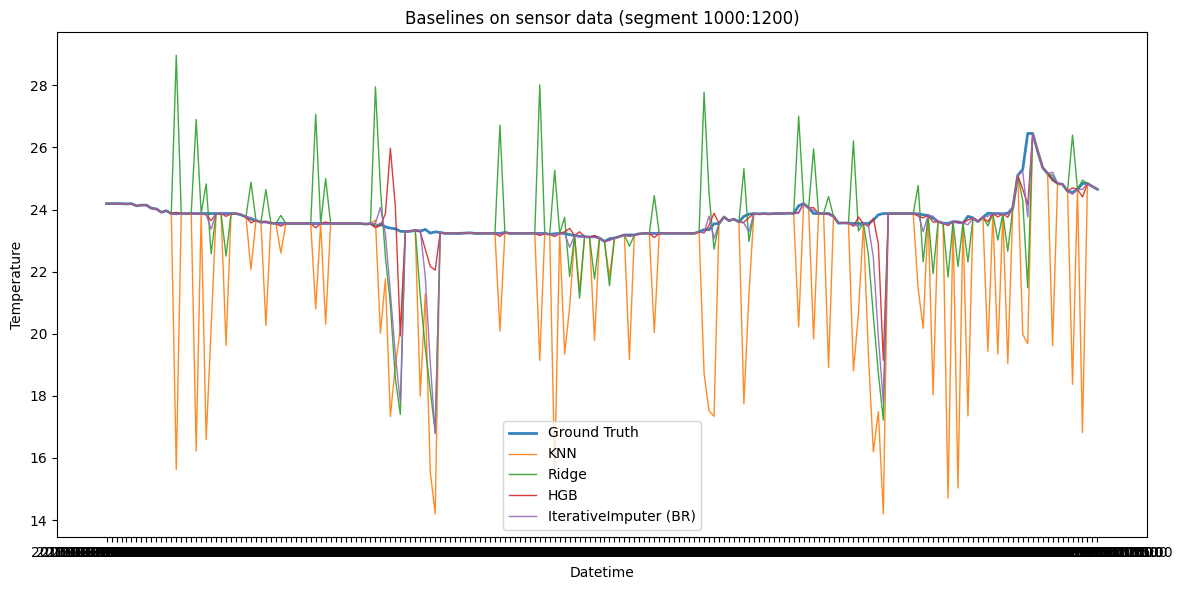

In [ ]:
# === Section: Plotting II — representative segment per position ===
import matplotlib.pyplot as plt
segment_len = min(500, N)
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, position in zip(axes, missing_positions):
    mask = results[position]['mask']
    imputations = results[position]['imputations']
    if position == 'START':
        segment_start = 0
    elif position == 'MIDDLE':
        segment_start = max(0, (N - segment_len) // 2)
    elif position == 'END':
        segment_start = max(0, N - segment_len)
    else:
        missing_indices = np.flatnonzero(~mask)
        if missing_indices.size:
            center_index = int(np.median(missing_indices))
            segment_start = max(0, center_index - segment_len // 2)
            segment_start = min(segment_start, max(0, N - segment_len))
        else:
            segment_start = 0
    segment_end = min(N, segment_start + segment_len)
    idx = df.index[segment_start:segment_end]

    observed_segment = data.copy().astype(float)
    observed_segment[~mask] = np.nan

    ax.plot(idx, data[segment_start:segment_end], label='Ground Truth', linewidth=1)
    ax.plot(idx, observed_segment[segment_start:segment_end], label='Observed (masked)', linewidth=1)
    ax.plot(idx, imputations['KNN Regressor'][segment_start:segment_end], label='KNN', linewidth=1, alpha=0.9)
    ax.plot(idx, imputations['Ridge Regression'][segment_start:segment_end], label='Ridge', linewidth=1, alpha=0.9)
    ax.plot(idx, imputations['HistGradientBoosting'][segment_start:segment_end], label='HGB', linewidth=1, alpha=0.9)
    ax.plot(idx, imputations['IterativeImputer (BR)'][segment_start:segment_end], label='IterativeImputer (BR)', linewidth=1, alpha=0.9)

    ax.set_title(f'{position} missingness')
    ax.set_xlabel('Datetime')
    ax.set_ylabel('Temperature')
    ax.legend(fontsize=8)

fig.suptitle('ML Baselines on sensor data (representative segments)', y=1.02)
fig.tight_layout()
plt.show()